# Task 0 - Exploratory Data Analysis

## Required Imports

In [ ]:
import numpy as np
import networkx as nx

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Load Dataset and Construct MultiDiGraph with Features

In [ ]:
df_links = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/links.csv")
print(df_links)

       Source  Target
0           0     117
1           0     491
2           0     603
3           0     773
4           0    1020
...       ...     ...
17230    1975    1038
17231    1975    1254
17232    1975    1381
17233    1975    1719
17234    1975    1765

[17235 rows x 2 columns]


In [ ]:
df_nodes = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/nodes.csv", sep="\t")
print(df_nodes.head(1))

   Page ID                        Name            Creation Date   Type  \
0        0  In_popular_culture_content  2007-02-12 18:56:47 UTC  Essay   

   Louvain Community  Final In Degree  EC Estimate  \
0                  1                0     0.000163   

   Fraction of total pageviews (July 2015)  Number of Edits  Unique Editors  \
0                                 0.000205              399             171   

   Number of Talk Page Edits  Unique Talk Page Editors  Page Size  
0                        267                       267       1560  


In [ ]:
df_topics = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/topics.csv", sep="\t")
print(df_topics.head(1))

   Page ID  Number of Words       Topic 1   Topic 2       Topic 3   Topic 4  \
0        0            959.0  1.710234e-19  0.076057  2.305177e-19  0.653648   

        Topic 5   Topic 6       Topic 7   Topic 8  ...      Topic 11  \
0  1.143827e-19  0.034452  1.117835e-19  0.235844  ...  1.289104e-19   

       Topic 12      Topic 13      Topic 14      Topic 15      Topic 16  \
0  1.473083e-19  1.676075e-19  1.812079e-19  1.077796e-19  1.215833e-19   

       Topic 17      Topic 18      Topic 19      Topic 20  
0  9.847681e-20  1.560968e-19  2.410273e-19  1.947174e-19  

[1 rows x 22 columns]


In [ ]:
df_all_node_features = df_nodes.merge(df_topics, on="Page ID", how="left")
print(df_all_node_features.columns)

Index(['Page ID', 'Name', 'Creation Date', 'Type', 'Louvain Community',
       'Final In Degree', 'EC Estimate',
       'Fraction of total pageviews (July 2015)', 'Number of Edits',
       'Unique Editors', 'Number of Talk Page Edits',
       'Unique Talk Page Editors', 'Page Size', 'Number of Words', 'Topic 1',
       'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7',
       'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13',
       'Topic 14', 'Topic 15', 'Topic 16', 'Topic 17', 'Topic 18', 'Topic 19',
       'Topic 20'],
      dtype='object')


In [ ]:
# Consulted official NetworkX documentation at:
# https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html

G = nx.from_pandas_edgelist(df_links, source="Source", target="Target", create_using=nx.MultiDiGraph)
# Note there are some nodes that don't have all topic attributes
G.add_nodes_from((n, dict(d)) for n, d in df_all_node_features.iterrows())
print(G)
print(G.nodes[0])

MultiDiGraph with 1976 nodes and 17235 edges
{'Page ID': 0, 'Name': 'In_popular_culture_content', 'Creation Date': '2007-02-12 18:56:47 UTC', 'Type': 'Essay', 'Louvain Community': 1, 'Final In Degree': 0, 'EC Estimate': 0.0001626162778894, 'Fraction of total pageviews (July 2015)': 0.0002048444547773, 'Number of Edits': 399, 'Unique Editors': 171, 'Number of Talk Page Edits': 267, 'Unique Talk Page Editors': 267, 'Page Size': 1560, 'Number of Words': 959.0000000000008, 'Topic 1': 1.7102336566440234e-19, 'Topic 2': 0.0760565545515698, 'Topic 3': 2.3051774762843663e-19, 'Topic 4': 0.6536475757107106, 'Topic 5': 1.1438267247712907e-19, 'Topic 6': 0.0344516308097106, 'Topic 7': 1.1178345700816128e-19, 'Topic 8': 0.2358442389280088, 'Topic 9': 1.7296337030998024e-19, 'Topic 10': 1.632536850442116e-19, 'Topic 11': 1.289104362176843e-19, 'Topic 12': 1.4730825295684649e-19, 'Topic 13': 1.6760750797243862e-19, 'Topic 14': 1.8120792587481965e-19, 'Topic 15': 1.0777963642246984e-19, 'Topic 16': 1

## Recreating Original Paper's Network Plots

**In Graph 1**
* Nodes are Wikipedia norm pages.  
* Edges are directed hyperlinks between those pages.
* Node color encodes Louvain community.

**In Graph 2**
* Nodes are Wikipedia norm Louvain communities.  
* Edges are directed hyperlinks between those communities.
* Node color encodes Louvain community.
* Node size encodes the number of pages in that community.
* Edge weight encodes the fraction of the source cluster’s outlinks to the target cluster.
* Edge color encodes the source Louvain community.

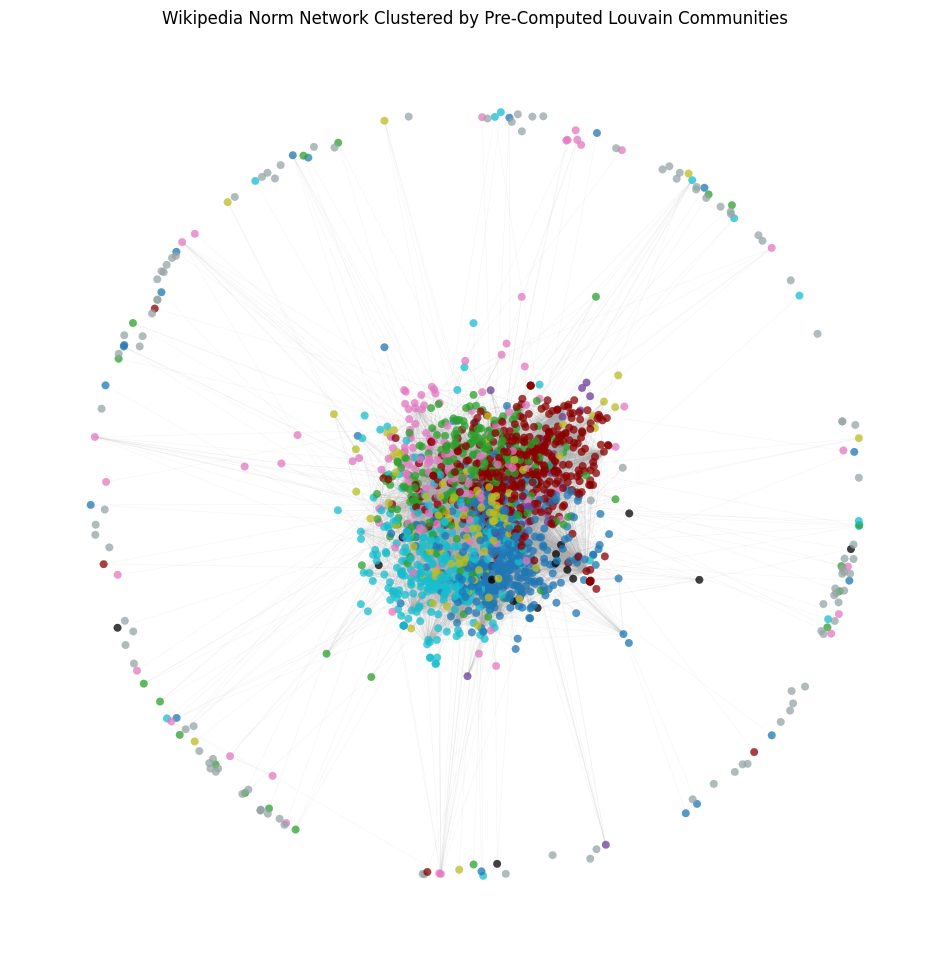

In [ ]:
community_labels = {1: "Article Quality",
                    2: "Collaboration",
                    3: "Administrators",
                    4: "Formatting Articles",
                    5: "Content Policies",
                    6: "Wiki-larping",
                    7: "Page Templates",
                    8: "Experts and Credentials",
                    9: "Humor"}

community_colors = {1: "#8B0000",
                    2: "#1f77b4",
                    3: "#17becf",
                    4: "#2ca02c",
                    5: "#e377c2",
                    6: "#bcbd22",
                    7: "#6c3d99",
                    8: "#2980b9",
                    9: "#000000",
                    10: "#95a5a6",
                    -1: "#95a5a6"}

node_colors = np.array([community_colors[comm] for comm in nx.get_node_attributes(G, "Louvain Community").values()])
pos = nx.forceatlas2_layout(G, scaling_ratio=15, gravity=5)
fig, ax = plt.subplots(figsize=(12, 12))

# We will add community labels to the graph manually
nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="#aaaaaa", alpha=0.12, width=0.4, arrows=False)
nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_size=30, node_color=node_colors, alpha=0.75, linewidths=0.2)
ax.set_title("Wikipedia Norm Network Clustered by Pre-Computed Louvain Communities")
ax.axis("off")
plt.show()

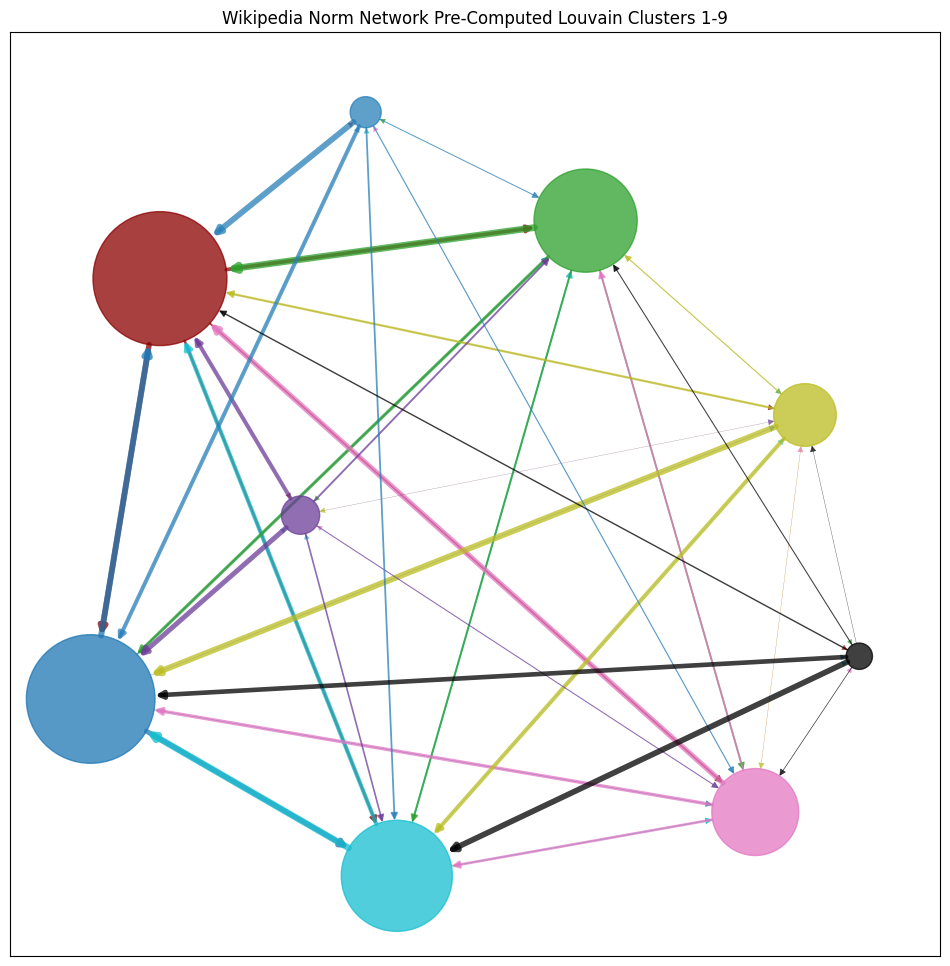

In [ ]:
# Make community list
communities = [[],[],[],[],[],[],[],[],[],[],[]]
for node, comm in nx.get_node_attributes(G, "Louvain Community").items():
  if comm == -1:
    communities[10].append(node)
  else:
    communities[comm-1].append(node)

node_to_comm = nx.get_node_attributes(G, "Louvain Community")

node_sizes = [len(i) * 20 for i in communities[:-2]]
edge_weights = {}
outgoing_edges = {}

# Track edges between communities 1-9
for _, row in df_links.iterrows():
    source, target = row["Source"], row["Target"]
    source_comm = node_to_comm.get(source)
    target_comm = node_to_comm.get(target)
    if source_comm == -1 or source_comm == 10:
      continue
    if target_comm == -1 or target_comm == 10:
      continue

    if source_comm != target_comm:
      edge = (source_comm, target_comm)
      edge_weights[edge] = edge_weights.get(edge, 0) + 1

# Plot according to community size & inter-community edge fractions (only for comms 1-9)
community_graph = nx.DiGraph()

for i in range(len(communities[:-2])):
  community_graph.add_node(i+1)

for (source_comm, target_comm), count in edge_weights.items():
  outgoing_edges[source_comm] = outgoing_edges.get(source_comm, 0) + count

for (source_comm, target_comm), count in edge_weights.items():
  community_graph.add_edge(source_comm, target_comm, weight=count * 10 / outgoing_edges.get(source_comm))

node_colors = np.array([community_colors[node] for node in community_graph.nodes])
edge_colors = np.array([community_colors[source_comm] for source_comm, _ in community_graph.edges])
weight_list = [v for v in nx.get_edge_attributes(community_graph, "weight").values()]
pos = nx.forceatlas2_layout(community_graph, weight="weight", scaling_ratio=6)

plt.figure(figsize=(12,12))
plt.title("Wikipedia Norm Network Pre-Computed Louvain Clusters 1-9")
nx.draw_networkx(community_graph, pos=pos, edge_color=edge_colors, width=weight_list, node_size=node_sizes, alpha=0.75, node_color=node_colors, with_labels=False)

## Visualizing Network Statistics

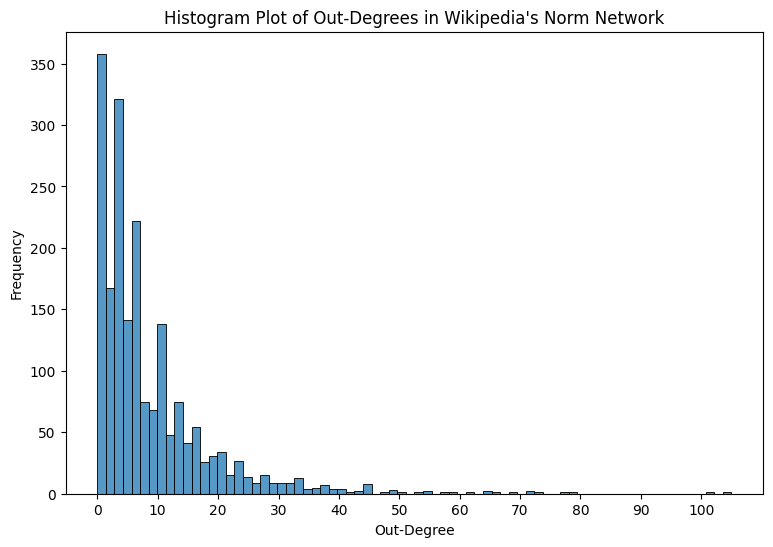

In [ ]:
outdegrees = []

for node, d in list(G.out_degree):
  outdegrees.append(d)

plt.figure(figsize=(9,6))
plt.title("Histogram Plot of Out-Degrees in Wikipedia's Norm Network")
plt.xlabel("Out-Degree")
plt.xticks(np.arange(min(outdegrees), max(outdegrees), 10))
plt.ylabel("Frequency")
sns.histplot(outdegrees, legend=False)
plt.show()

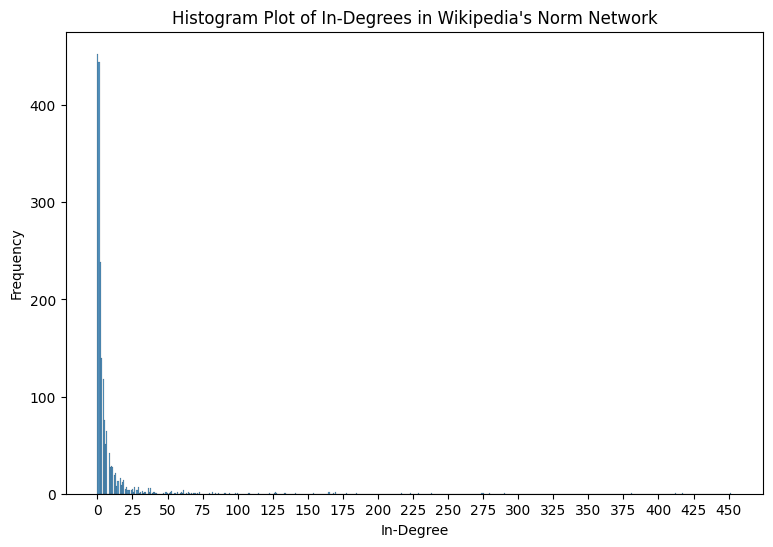

In [ ]:
indegrees = []
for node, d in list(G.in_degree):
  indegrees.append(d)

plt.figure(figsize=(9,6))
plt.title("Histogram Plot of In-Degrees in Wikipedia's Norm Network")
plt.xlabel("In-Degree")
plt.xticks(np.arange(min(indegrees), max(indegrees), 25))
plt.ylabel("Frequency")
sns.histplot(indegrees, legend=False)
plt.show()

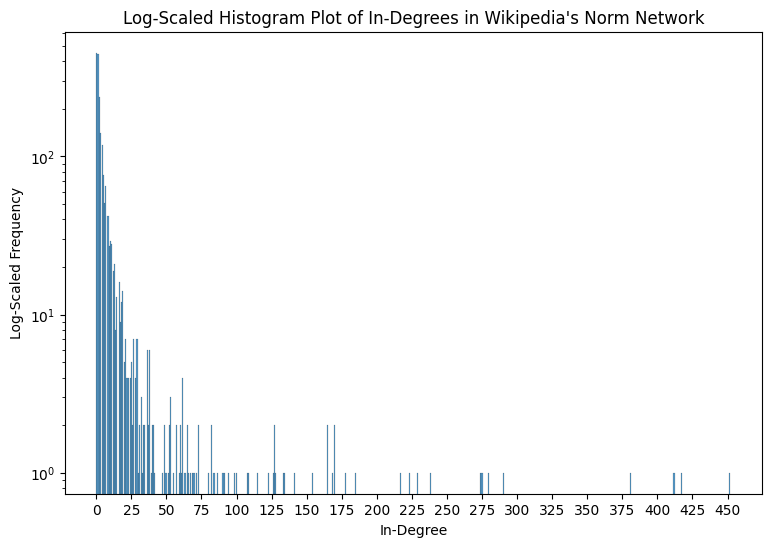

In [ ]:
plt.figure(figsize=(9,6))
plt.title("Log-Scaled Histogram Plot of In-Degrees in Wikipedia's Norm Network")
plt.xlabel("In-Degree")
plt.xticks(np.arange(min(indegrees), max(indegrees), 25))
plt.yscale("log")
plt.ylabel("Log-Scaled Frequency")
sns.histplot(indegrees, legend=False)
plt.show()